In [18]:
from hci import lib
import ctypes
import numpy as np
import math
import pyscf
from pyscf import gto, scf

libhci = lib.libhci
rng = np.random.default_rng()

# Ranking and indexing

In [14]:
norb = 8
nocc = 4
combs = np.empty(min(nocc, norb-nocc)+1, dtype=np.uint64)
inverted = libhci.get_consecutive_combs(combs.ctypes.data_as(ctypes.c_void_p), 
                 ctypes.c_size_t(norb),
                 ctypes.c_size_t(nocc))
print(inverted, combs)

0 [ 1  8 28 56 70]


In [15]:
norb = 8
nocc = 4
rank_table = np.empty((nocc, norb-nocc+1), dtype=np.uint64, order='C')
libhci.get_rank_table(rank_table.ctypes.data_as(ctypes.c_void_p),
                                       ctypes.c_size_t(norb),
                                       ctypes.c_size_t(nocc))
print(rank_table)

[[ 0  1  2  3  4]
 [ 0  1  3  6 10]
 [ 0  1  4 10 20]
 [ 0  1  5 15 35]]


In [16]:
rank = 0
index = libhci.find_row_index(ctypes.c_uint64(rank),
                              rank_table[2][:].ctypes.data_as(ctypes.c_void_p),
                              ctypes.c_size_t(norb),
                              ctypes.c_size_t(nocc))
print(index)

0


In [17]:
import itertools
norb = 8
nocc = 4
# occ_list = np.array([1,3,4,5], dtype=np.int32)
for comb in itertools.combinations(np.arange(norb, dtype=np.uintp), nocc):
    occ_list = np.array(comb)
    rank = libhci.rank(occ_list.ctypes.data_as(ctypes.c_void_p),
                       rank_table.ctypes.data_as(ctypes.c_void_p),
                       ctypes.c_size_t(norb),
                       ctypes.c_size_t(nocc))
    print(occ_list, rank)

[0 1 2 3] 0
[0 1 2 4] 1
[0 1 2 5] 5
[0 1 2 6] 15
[0 1 2 7] 35
[0 1 3 4] 2
[0 1 3 5] 6
[0 1 3 6] 16
[0 1 3 7] 36
[0 1 4 5] 9
[0 1 4 6] 19
[0 1 4 7] 39
[0 1 5 6] 25
[0 1 5 7] 45
[0 1 6 7] 55
[0 2 3 4] 3
[0 2 3 5] 7
[0 2 3 6] 17
[0 2 3 7] 37
[0 2 4 5] 10
[0 2 4 6] 20
[0 2 4 7] 40
[0 2 5 6] 26
[0 2 5 7] 46
[0 2 6 7] 56
[0 3 4 5] 12
[0 3 4 6] 22
[0 3 4 7] 42
[0 3 5 6] 28
[0 3 5 7] 48
[0 3 6 7] 58
[0 4 5 6] 31
[0 4 5 7] 51
[0 4 6 7] 61
[0 5 6 7] 65
[1 2 3 4] 4
[1 2 3 5] 8
[1 2 3 6] 18
[1 2 3 7] 38
[1 2 4 5] 11
[1 2 4 6] 21
[1 2 4 7] 41
[1 2 5 6] 27
[1 2 5 7] 47
[1 2 6 7] 57
[1 3 4 5] 13
[1 3 4 6] 23
[1 3 4 7] 43
[1 3 5 6] 29
[1 3 5 7] 49
[1 3 6 7] 59
[1 4 5 6] 32
[1 4 5 7] 52
[1 4 6 7] 62
[1 5 6 7] 66
[2 3 4 5] 14
[2 3 4 6] 24
[2 3 4 7] 44
[2 3 5 6] 30
[2 3 5 7] 50
[2 3 6 7] 60
[2 4 5 6] 33
[2 4 5 7] 53
[2 4 6 7] 63
[2 5 6 7] 67
[3 4 5 6] 34
[3 4 5 7] 54
[3 4 6 7] 64
[3 5 6 7] 68
[4 5 6 7] 69


In [18]:
norb = 8
nocc = 4

rank_table = np.empty((nocc, norb-nocc+1), dtype=np.uint64)
libhci.get_rank_table(rank_table.ctypes.data_as(ctypes.c_void_p),
                                       ctypes.c_size_t(norb),
                                       ctypes.c_size_t(nocc))
print(rank_table)

rank = 57
occ_list = np.zeros(nocc, dtype=np.uintp)
libhci.unrank(ctypes.c_uint64(rank),
              occ_list.ctypes.data_as(ctypes.c_void_p),
              rank_table.ctypes.data_as(ctypes.c_void_p),
              ctypes.c_size_t(norb),
              ctypes.c_size_t(nocc))
print(occ_list)

[[ 0  1  2  3  4]
 [ 0  1  3  6 10]
 [ 0  1  4 10 20]
 [ 0  1  5 15 35]]
[1 2 6 7]


# Double excitation storage

In [5]:
from hci import lib
import numpy as np
libhci = lib.libhci
rng = np.random.default_rng()

norb = 10
na = 5
nb = 3
config_table_a, config_table_b, exc_table_4o, exc_table_2o = lib.get_ranking_tables(norb, (na, nb))

print(config_table_a)
print(config_table_b)
print(exc_table_4o)
print(exc_table_2o)

nij = norb*(norb+1)//2
mock_eri_s8 = rng.random(nij*(nij+1)//2)
mock_eri_s4 = rng.random(nij**2)

doubles_aa = lib.get_stored_double_exc(mock_eri_s8, exc_table_4o, norb)
max_mag_aa = lib.get_max_magnitudes(doubles_aa, norb)
doubles_aa = doubles_aa[np.argsort(max_mag_aa)[::-1]]

doubles_bb = lib.get_stored_double_exc(mock_eri_s8, exc_table_4o, norb)
max_mag_bb = lib.get_max_magnitudes(doubles_bb, norb)
doubles_bb = doubles_bb[np.argsort(max_mag_bb)[::-1]]

mixed_ab = lib.get_stored_mixed_exc(mock_eri_s4, exc_table_2o, norb)
max_mag_ab = np.abs(mixed_ab['ijkl'])
mixed_ab = mixed_ab[np.argsort(max_mag_ab)[::-1]]

print(doubles_aa)
print(doubles_bb)
print(mixed_ab)

[[  0   1   2   3   4   5]
 [  0   1   3   6  10  15]
 [  0   1   4  10  20  35]
 [  0   1   5  15  35  70]
 [  0   1   6  21  56 126]]
[[ 0  1  2  3  4  5  6  7]
 [ 0  1  3  6 10 15 21 28]
 [ 0  1  4 10 20 35 56 84]]
[[  0   1   2   3   4   5   6]
 [  0   1   3   6  10  15  21]
 [  0   1   4  10  20  35  56]
 [  0   1   5  15  35  70 126]]
[[ 0  1  2  3  4  5  6  7  8]
 [ 0  1  3  6 10 15 21 28 36]]
[( 89, 0.89001722, 0.95347607) ( 60, 0.93436867, 0.90179943)
 (136, 0.86425904, 0.88722663) ( 28, 0.76508044, 0.9805035 )
 (135, 0.83995598, 0.90179943) (150, 0.83995598, 0.90179943)
 (114, 0.79462776, 0.91483346) ( 35, 0.78214707, 0.92373149)
 (115, 0.92782405, 0.74832616) ( 91, 0.9805035 , 0.67441441)
 ( 73, 0.76061558, 0.88722663) (184, 0.92782405, 0.71880681)
 ( 40, 0.76061558, 0.88507205) ( 58, 0.80199645, 0.83995598)
 ( 88, 0.92782405, 0.70227591) (193, 0.71880681, 0.89001722)
 (195, 0.65583055, 0.93378647) (151, 0.92782405, 0.65196538)
 (139, 0.88722663, 0.69025843) (128, 0.68685507

In [14]:
magnitudes = np.empty(math.comb(norb, 4), dtype=np.double)
libhci.get_max_magnitudes(double_excitations_aaaa.ctypes.data_as(ctypes.c_void_p),
                          magnitudes.ctypes.data_as(ctypes.c_void_p),
                          ctypes.c_size_t(math.comb(norb,4)))
print(magnitudes)

[1.43138825 0.95490133 1.58294308 0.96172623 0.56182144 1.7285025
 0.83095294 1.13340277 0.77336095 0.61131428 1.68196383 0.45185043
 0.5370003  0.24550816 0.60466945 0.6771271  0.96172623 1.03023244
 0.96923076 0.48885992 0.40175945 1.48991151 0.87309136 0.76503764
 0.75535855 1.44908453 0.92721395 0.93717836 1.10992139 0.3760649
 0.9098485  0.36118519 0.83462684 1.22269986 0.6734003  1.45257744
 1.01913035 0.41053953 0.7333437  1.68196383 0.97795319 1.02535781
 1.36090263 0.83962549 1.43293493 0.8245309  0.58654529 0.32530424
 0.51627513 0.85632432 1.18988381 1.00736987 1.14299478 1.54218654
 0.89141365 1.10876269 0.28237779 0.3218933  0.48844259 0.78945421
 1.23007208 0.86167597 0.92121139 0.65670874 1.2603617  1.15898853
 0.9371221  0.4054812  0.79063353 0.98682543]


In [15]:
print(magnitudes-(double_excitations_aaaa['ijkl']+double_excitations_aaaa['iljk']))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


# Subspace enlargement

## H2 - mixed only

In [1]:
import hci.hci_uhf
from pyscf import gto, scf
from pyscf.fci.direct_spin1 import _unpack_nelec

In [2]:
mol = gto.M(
    atom = '''
H    -0.340000    0.000000    0.000000
H    0.340000    0.000000    0.000000''',
    basis = '3-21g',
    charge = 0,
    spin = 0  # = 2S = spin_up - spin_down
)

In [3]:
mf = scf.UHF(mol)
mf.kernel()

converged SCF energy = -1.12046039838593  <S^2> = 4.4408921e-16  2S+1 = 1


np.float64(-1.120460398385931)

In [4]:
mf.scf_summary

{'nuc': np.float64(0.7782017807647059),
 'e1': np.float64(-2.5736793011584425),
 'e2': np.float64(0.6750171220078056)}

In [5]:
nelec = _unpack_nelec(mol.nelectron, mol.spin)
nao = mol.nao_nr()
mo = mf.mo_coeff
norb = mo.shape[1]
hcore = mf.get_hcore()
eri_ao = mf._eri
print(norb, nelec)
print(mo)

4 (1, 1)
[[[ 0.29920008  0.10240537  0.75808043 -1.12464738]
  [ 0.29744806  1.77543079 -0.65876995  1.31493919]
  [ 0.29920008 -0.10240537  0.75808043  1.12464738]
  [ 0.29744806 -1.77543079 -0.65876995 -1.31493919]]

 [[ 0.2992001   0.10240537  0.75808042  1.12464738]
  [ 0.29744805  1.77543078 -0.65876996 -1.3149392 ]
  [ 0.2992001  -0.10240537  0.75808042 -1.12464738]
  [ 0.29744805 -1.77543078 -0.65876996  1.3149392 ]]]


In [10]:
hci.hci_uhf.kernel(hcore, eri_ao, mo, norb, nelec, 0.1)

aa: [(0, 4.75522762e-17, 0.11841575)]
bb: [(0, -6.19870065e-17, 0.11841574)]
ab: [( 7,  4.07364481e-01) (35, -1.37319570e-01) (21,  1.18415744e-01)
 (15,  1.18415744e-01) (14,  1.18415744e-01) (20,  1.18415744e-01)
 ( 0,  8.24893642e-02) ( 5,  7.90993359e-02) (30, -7.90993352e-02)
 (13,  5.13708578e-02) (19,  5.13708578e-02) ( 8,  5.13708558e-02)
 ( 9,  5.13708558e-02) (28,  3.68701063e-02) ( 4, -2.24259416e-02)
 (24, -2.24259388e-02) (29,  2.00916579e-02) (34, -2.00916563e-02)
 (10, -8.02336393e-16) (11,  6.72017894e-16) (31, -3.97045029e-16)
 (33, -2.45267281e-16) (32, -2.45267281e-16) ( 1, -2.10547275e-16)
 ( 6, -1.67949176e-16) (16, -1.63930323e-16) (22, -1.63930323e-16)
 (18, -1.56058781e-16) (12, -1.56058781e-16) (25, -1.30326862e-16)
 ( 2,  1.25239733e-16) ( 3,  1.25239733e-16) (26,  5.45421766e-17)
 (27,  5.45421766e-17) (17, -4.15330713e-17) (23, -4.15330713e-17)]

[(0, 0, 1.)]

[[2 2]
 [3 3]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]]


array([(0, 0, 1.)],
      dtype=[('arank', '<u8'), ('brank', '<u8'), ('coeff', '<f8')])

In [26]:
mixed_rank = 20
config_table_a, config_table_b, exc_table_4o, exc_table_2o = hci.lib.get_ranking_tables(4, (1,1))
occ_list = np.empty(4, dtype=np.uint64)
hci.lib.libhci.unrank_mixed(ctypes.c_uint64(mixed_rank), 
                            occ_list.ctypes.data_as(ctypes.c_void_p),
                            exc_table_2o.ctypes.data_as(ctypes.c_void_p),
                            ctypes.c_size_t(4))
print(occ_list)
    #  unrank_mixed(uint64_t rank, size_t *occ_list, uint64_t *rank_table, size_t norb);

[0 3 1 2]


## Water - all types

In [1]:
import hci.hci_uhf
from pyscf import gto, scf, ao2mo
from pyscf.fci.direct_spin1 import _unpack_nelec
import numpy as np
import ctypes
from functools import reduce
import math

In [2]:
mol = gto.M(
    atom = '''
O        0.000000    0.000000    0.117790
H        0.000000    0.755453   -0.471161
H        0.000000   -0.755453   -0.471161''',
    basis = 'sto-3g',
    charge = 1,
    spin = 1  # = 2S = spin_up - spin_down
)

In [3]:
mf = scf.UHF(mol)
mf.kernel()

converged SCF energy = -74.6557767322148  <S^2> = 0.75520546  2S+1 = 2.0051987


np.float64(-74.65577673221479)

In [4]:
mf.scf_summary

{'nuc': np.float64(9.189193229309746),
 'e1': np.float64(-116.41508892506984),
 'e2': np.float64(32.5701189635453)}

In [5]:
nelec = _unpack_nelec(mol.nelectron, mol.spin)
nao = mol.nao_nr()
mo = mf.mo_coeff
norb = mo.shape[1]
hcore = mf.get_hcore()
eri_ao = mf._eri
print(norb, nelec)

7 (5, 4)


In [6]:
hci.hci_uhf.kernel(hcore, eri_ao, mo, norb, nelec, 0.02)

aa: [(27, -0.06755659,  0.03792697) (21, -0.03571627,  0.0332249 )
 (15,  0.0313598 , -0.00863432) (33, -0.02854876,  0.02967796)
 ( 9,  0.02031878, -0.00117655)]
bb: [(27,  0.06706353, -0.04203109) (18,  0.03669653, -0.03353478)
 (15, -0.0304591 ,  0.00907646) (30,  0.02877651, -0.02850987)]
ab: [( 91,  0.15043484) ( 44,  0.14936719) (440, -0.14594924)
 (374, -0.14476726) (151,  0.12402325) (422, -0.10610621)
 ( 62,  0.09902151) (242,  0.09003586) (368, -0.07821753)
 (432,  0.07682747) (248,  0.07139198) (272, -0.07028913)
 ( 60,  0.06847144) (311, -0.06789767) (401, -0.06599375)
 (361, -0.06532727) (164,  0.06293711) (264,  0.06288088)
 (370,  0.06166833) ( 98,  0.06155957) (  0,  0.06137303)
 (305, -0.06056353) (438, -0.06029267) (419, -0.05886296)
 (198,  0.05614044) (417, -0.05457312) (307,  0.05281065)
 (280,  0.05262425) (244, -0.05217194) (352, -0.05042458)
 ( 93,  0.047152  ) (173,  0.04421887) ( 58,  0.03898099)
 ( 10,  0.0379773 ) (425,  0.03674387) (411,  0.03623084)
 (196,

array([(0, 0, 1.)],
      dtype=[('arank', '<u8'), ('brank', '<u8'), ('coeff', '<f8')])

In [7]:
config_table_a, config_table_b, exc_table_4o, exc_table_2o = hci.lib.get_ranking_tables(7, (5, 4))

In [8]:
a_rank = 18
b_rank = 0
occ_a = np.empty(5, dtype=np.uint64)
occ_b = np.empty(4, dtype=np.uint64)
hci.lib.libhci.unrank(ctypes.c_uint64(a_rank), 
                      occ_a.ctypes.data_as(ctypes.c_void_p),
                      config_table_a.ctypes.data_as(ctypes.c_void_p),
                      ctypes.c_size_t(7),
                      ctypes.c_size_t(5))
hci.lib.libhci.unrank(ctypes.c_uint64(b_rank), 
                      occ_b.ctypes.data_as(ctypes.c_void_p),
                      config_table_b.ctypes.data_as(ctypes.c_void_p),
                      ctypes.c_size_t(7),
                      ctypes.c_size_t(4))
print(occ_a, occ_b)

[0 3 4 5 6] [0 1 2 3]


In [9]:
exc_rank_aa = 27
exc_aa = np.empty(4, dtype=np.uint64)
hci.lib.libhci.unrank(ctypes.c_uint64(exc_rank_aa), 
                      exc_aa.ctypes.data_as(ctypes.c_void_p),
                      exc_table_4o.ctypes.data_as(ctypes.c_void_p),
                      ctypes.c_size_t(7),
                      ctypes.c_size_t(4))
print(exc_aa)

[1 2 5 6]


In [10]:
exc_rank_bb = 0
exc_bb = np.empty(4, dtype=np.uint64)
hci.lib.libhci.unrank(ctypes.c_uint64(exc_rank_bb), 
                      exc_bb.ctypes.data_as(ctypes.c_void_p),
                      exc_table_4o.ctypes.data_as(ctypes.c_void_p),
                      ctypes.c_size_t(7),
                      ctypes.c_size_t(4))
print(exc_bb)

[0 1 2 3]


In [11]:
mo_a, mo_b = mo
nelec_a, nelec_b = nelec
h1e_aa = reduce(np.dot, (mo_a.conj().T, hcore, mo_a))
h1e_bb = reduce(np.dot, (mo_b.conj().T, hcore, mo_b))
eri_mo_aaaa_s1 = ao2mo.restore('s1', ao2mo.full(eri_ao, mo_a), norb)
eri_mo_bbbb_s1 = ao2mo.restore('s1', ao2mo.full(eri_ao, mo_b), norb)
eri_mo_aabb_s1 = ao2mo.restore('s1', ao2mo.general(eri_ao, [mo_a, mo_a, mo_b, mo_b]), norb)

In [12]:
def index_2d(i, j):
    if i>j:
        return math.comb(i+1, 2)+j
    else:
        return math.comb(j+1, 2)+i

def index_4d(i, j, k, l):
    return index_2d(index_2d(i, j), index_2d(k, l))

In [13]:
eri_mo_aaaa_s8 = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_a), norb)
i = 1
j = 2
k = 5
l = 6
print(eri_mo_aaaa_s1[i,j,k,l]-eri_mo_aaaa_s1[i,l,k,j])
print(eri_mo_aaaa_s8[index_4d(i,j,k,l)]-eri_mo_aaaa_s8[index_4d(i,l,k,j)])

-0.06755658843298308
-0.0675565884329831


## Full testing script

In [1]:
import hci.hci_uhf
from pyscf import gto, scf, ao2mo
from pyscf.fci.direct_spin1 import _unpack_nelec
import numpy as np
import ctypes
from functools import reduce
import math

In [2]:
mol = gto.M(
    atom = '''
O        0.000000    0.000000    0.117790
H        0.000000    0.755453   -0.471161
H        0.000000   -0.755453   -0.471161''',
    basis = 'sto-3g',
    charge = 1,
    spin = 1  # = 2S = spin_up - spin_down
)

In [3]:
mf = scf.UHF(mol)
mf.kernel()

converged SCF energy = -74.6557767322148  <S^2> = 0.75520546  2S+1 = 2.0051987


np.float64(-74.6557767322148)

In [4]:
mf.scf_summary

{'nuc': np.float64(9.189193229309746),
 'e1': np.float64(-116.41508892506985),
 'e2': np.float64(32.57011896354529)}

In [5]:
nelec = _unpack_nelec(mol.nelectron, mol.spin)
nao = mol.nao_nr()
mo = mf.mo_coeff
norb = mo.shape[1]
hcore = mf.get_hcore()
eri_ao = mf._eri
print(norb, nelec)

7 (5, 4)


In [6]:
mo_a, mo_b = mo
nelec_a, nelec_b = nelec
h1e_aa = reduce(np.dot, (mo_a.conj().T, hcore, mo_a))
h1e_bb = reduce(np.dot, (mo_b.conj().T, hcore, mo_b))
eri_mo_aaaa = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_a), norb)
eri_mo_bbbb = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_b), norb)
eri_mo_aabb = ao2mo.restore('s4', ao2mo.general(eri_ao, [mo_a, mo_a, mo_b, mo_b]), norb)

In [7]:
config_table_a, config_table_a_complement, config_table_b, config_table_b_complement, exc_table_4o, exc_table_2o = hci.lib.get_ranking_tables(norb, nelec)

In [8]:
doubles_aa = hci.lib.get_stored_double_exc(eri_mo_aaaa, exc_table_4o, norb)

In [9]:
print(doubles_aa)

[( 0,  5.75965797e-17, -8.94471632e-19)
 ( 1,  9.30918358e-17, -3.85466921e-18)
 ( 2,  2.71206456e-17,  5.83815029e-19)
 ( 3, -1.69959673e-17,  1.65652712e-17)
 ( 4,  1.07649145e-17, -1.44649382e-17)
 ( 5,  1.93519334e-18, -4.09010579e-17)
 ( 6,  7.15064486e-17, -3.74504559e-18)
 ( 7, -5.12143462e-17,  5.05326830e-17)
 ( 8, -8.64270110e-17,  7.94284933e-17)
 ( 9,  2.03187800e-02, -1.17654898e-03)
 (10, -1.41287772e-16,  1.11234086e-16)
 (11, -2.16830744e-16,  1.76266620e-16)
 (12,  8.99348313e-19,  8.96669349e-19)
 (13, -5.95155521e-17,  6.41733963e-17)
 (14,  1.03249752e-16, -1.16980044e-19)
 (15,  3.13597976e-02, -8.63432154e-03)
 (16,  1.12293487e-16, -3.03205622e-17)
 (17, -1.57546553e-17, -1.20706122e-17)
 (18, -1.35596686e-16,  1.19130841e-16)
 (19,  1.36804744e-16, -6.17485191e-17)
 (20, -4.15750321e-03, -3.11445775e-03)
 (21, -3.57162742e-02,  3.32249047e-02)
 (22, -1.45996224e-17, -1.10020046e-17)
 (23, -1.25422421e-16,  1.19457637e-16)
 (24, -1.39079002e-17,  1.42187164e-17)


In [8]:
doubles_aa = hci.lib.get_stored_double_exc(eri_mo_aaaa, exc_table_4o, norb)
max_mag_aa = hci.lib.get_max_magnitudes(doubles_aa, norb)
sorted_indices = np.argsort(max_mag_aa)[::-1]
doubles_aa = doubles_aa[sorted_indices]
max_mag_aa = max_mag_aa[sorted_indices]

doubles_bb = hci.lib.get_stored_double_exc(eri_mo_bbbb, exc_table_4o, norb)
max_mag_bb = hci.lib.get_max_magnitudes(doubles_bb, norb)
sorted_indices = np.argsort(max_mag_bb)[::-1]
doubles_bb = doubles_bb[sorted_indices]
max_mag_bb = max_mag_bb[sorted_indices]

mixed_ab = hci.lib.get_stored_mixed_exc(eri_mo_aabb, exc_table_2o, norb)
max_mag_ab = np.abs(mixed_ab['ijkl'])
sorted_indices = np.argsort(max_mag_ab)[::-1]
mixed_ab = mixed_ab[sorted_indices]
max_mag_ab = max_mag_ab[sorted_indices]

In [9]:
ci0 = np.empty(1, dtype=hci.lib.hci_entry)
ci0[0] = (0, 0, 1.0)

### Double excitations

In [10]:
add_thresh = 0.01
add_list, nadd = hci.lib.enlarge_space_doubles(ci0, norb, nelec_a, nelec_b, add_thresh, 
                                           config_table_a, config_table_b, exc_table_4o, exc_table_2o, 
                                           doubles_aa, doubles_bb, mixed_ab,
                                           max_mag_aa, max_mag_bb, max_mag_ab)

In [11]:
a_occ = np.zeros(nelec_a, dtype=np.uint64)
b_occ = np.zeros(nelec_b, dtype=np.uint64)
hci.lib.unrank(0, a_occ, config_table_a, norb, nelec_a)
hci.lib.unrank(0, b_occ, config_table_b, norb, nelec_b)
ci0_astr = set(a_occ)
ci0_bstr = set(b_occ)
eri_mo_aaaa_s1 = ao2mo.restore('s1', eri_mo_aaaa, norb)
eri_mo_bbbb_s1 = ao2mo.restore('s1', eri_mo_bbbb, norb)
eri_mo_aabb_s1 = ao2mo.restore('s1', eri_mo_aabb, norb)
for entry in add_list[:nadd]:
    arank = entry[0]
    brank = entry[1]
    print(arank, brank)
    hci.lib.unrank(arank, a_occ, config_table_a, norb, nelec_a)
    hci.lib.unrank(brank, b_occ, config_table_b, norb, nelec_b)
    print(a_occ, b_occ)
    excdet_astr = set(a_occ)
    excdet_bstr = set(b_occ)
    holeorbs_a = ci0_astr - excdet_astr
    holeorbs_b = ci0_bstr - excdet_bstr
    partorbs_a = excdet_astr - ci0_astr
    partorbs_b = excdet_bstr - ci0_bstr
    print(holeorbs_a, holeorbs_b, partorbs_a, partorbs_b)
    assert(len(holeorbs_a) + len(holeorbs_b) == 2)
    assert(len(partorbs_a) + len(partorbs_b) == 2)
    if len(holeorbs_a)==2:
        print(f'aa excitation from orbitals {holeorbs_a} to {partorbs_a}')
        sorted_holeorbs_a = sorted(holeorbs_a)
        sorted_partorbs_a = sorted(partorbs_a)
        a = sorted_holeorbs_a[0]
        b = sorted_holeorbs_a[1]
        c = sorted_partorbs_a[0]
        d = sorted_partorbs_a[1]
        val = abs(eri_mo_aaaa_s1[a,c,b,d]-eri_mo_aaaa_s1[a,d,b,c])
        assert(val > add_thresh)
    elif len(holeorbs_a)==1:
        print(f'ab excitation from a orbital {holeorbs_a} to {partorbs_a} and b orbital {holeorbs_b} to {partorbs_b}')
        a = holeorbs_a.pop()
        b = holeorbs_b.pop()
        c = partorbs_a.pop()
        d = partorbs_b.pop()
        val = abs(eri_mo_aabb_s1[a,c,b,d])
        assert(val > add_thresh)
    else:
        print(f'bb excitation from orbitals {holeorbs_b} to {partorbs_b}')
        sorted_holeorbs_b = sorted(holeorbs_b)
        sorted_partorbs_b = sorted(partorbs_b)
        a = sorted_holeorbs_b[0]
        b = sorted_holeorbs_b[1]
        c = sorted_partorbs_b[0]
        d = sorted_partorbs_b[1]
        val = abs(eri_mo_bbbb_s1[a,c,b,d]-eri_mo_bbbb_s1[a,d,b,c])
        assert(val > add_thresh)
    print()

18 0
[0 3 4 5 6] [0 1 2 3]
{np.uint64(1), np.uint64(2)} set() {np.uint64(5), np.uint64(6)} set()
aa excitation from orbitals {np.uint64(1), np.uint64(2)} to {np.uint64(5), np.uint64(6)}

19 0
[1 3 4 5 6] [0 1 2 3]
{np.uint64(0), np.uint64(2)} set() {np.uint64(5), np.uint64(6)} set()
aa excitation from orbitals {np.uint64(0), np.uint64(2)} to {np.uint64(5), np.uint64(6)}

0 28
[0 1 2 3 4] [0 3 5 6]
set() {np.uint64(1), np.uint64(2)} set() {np.uint64(5), np.uint64(6)}
bb excitation from orbitals {np.uint64(1), np.uint64(2)} to {np.uint64(5), np.uint64(6)}

0 29
[0 1 2 3 4] [1 3 5 6]
set() {np.uint64(0), np.uint64(2)} set() {np.uint64(5), np.uint64(6)}
bb excitation from orbitals {np.uint64(0), np.uint64(2)} to {np.uint64(5), np.uint64(6)}

8 16
[0 1 3 4 6] [0 1 3 6]
{np.uint64(2)} {np.uint64(2)} {np.uint64(6)} {np.uint64(6)}
ab excitation from a orbital {np.uint64(2)} to {np.uint64(6)} and b orbital {np.uint64(2)} to {np.uint64(6)}

4 7
[0 2 3 4 5] [0 2 3 5]
{np.uint64(1)} {np.uint64(1)}

### Single excitations

In [12]:
add_thresh = 0.0
add_list, nadd = hci.lib.enlarge_space_singles(ci0, norb, nelec_a, nelec_b, add_thresh,
                                               config_table_a, config_table_a_complement,
                                               config_table_b, config_table_b_complement,
                                               h1e_aa, h1e_bb, eri_mo_aaaa, eri_mo_bbbb, eri_mo_aabb)

In [13]:
a_occ = np.zeros(nelec_a, dtype=np.uint64)
b_occ = np.zeros(nelec_b, dtype=np.uint64)
hci.lib.unrank(0, a_occ, config_table_a, norb, nelec_a)
hci.lib.unrank(0, b_occ, config_table_b, norb, nelec_b)
ci0_astr = set(a_occ)
ci0_bstr = set(b_occ)
for entry in add_list[:nadd]:
    arank = entry[0]
    brank = entry[1]
    print(arank, brank)
    hci.lib.unrank(arank, a_occ, config_table_a, norb, nelec_a)
    hci.lib.unrank(brank, b_occ, config_table_b, norb, nelec_b)
    print(a_occ, b_occ)
    excdet_astr = set(a_occ)
    excdet_bstr = set(b_occ)
    holeorbs_a = ci0_astr - excdet_astr
    holeorbs_b = ci0_bstr - excdet_bstr
    partorbs_a = excdet_astr - ci0_astr
    partorbs_b = excdet_bstr - ci0_bstr
    print(holeorbs_a, holeorbs_b, partorbs_a, partorbs_b)
    assert(len(holeorbs_a) + len(holeorbs_b) == 1)
    assert(len(partorbs_a) + len(partorbs_b) == 1)
    if len(holeorbs_a)==1:
        print(f'a excitation from orbitals {holeorbs_a} to {partorbs_a}')
    else:
        print(f'b excitation from orbitals {holeorbs_b} to {partorbs_b}')
    print()

5 0
[1 2 3 4 5] [0 1 2 3]
{np.uint64(0)} set() {np.uint64(5)} set()
a excitation from orbitals {np.uint64(0)} to {np.uint64(5)}

10 0
[1 2 3 4 6] [0 1 2 3]
{np.uint64(0)} set() {np.uint64(6)} set()
a excitation from orbitals {np.uint64(0)} to {np.uint64(6)}

4 0
[0 2 3 4 5] [0 1 2 3]
{np.uint64(1)} set() {np.uint64(5)} set()
a excitation from orbitals {np.uint64(1)} to {np.uint64(5)}

9 0
[0 2 3 4 6] [0 1 2 3]
{np.uint64(1)} set() {np.uint64(6)} set()
a excitation from orbitals {np.uint64(1)} to {np.uint64(6)}

3 0
[0 1 3 4 5] [0 1 2 3]
{np.uint64(2)} set() {np.uint64(5)} set()
a excitation from orbitals {np.uint64(2)} to {np.uint64(5)}

8 0
[0 1 3 4 6] [0 1 2 3]
{np.uint64(2)} set() {np.uint64(6)} set()
a excitation from orbitals {np.uint64(2)} to {np.uint64(6)}

2 0
[0 1 2 4 5] [0 1 2 3]
{np.uint64(3)} set() {np.uint64(5)} set()
a excitation from orbitals {np.uint64(3)} to {np.uint64(5)}

7 0
[0 1 2 4 6] [0 1 2 3]
{np.uint64(3)} set() {np.uint64(6)} set()
a excitation from orbitals {

# Complement finding

In [57]:
norb = 13
nelec = 3
ncomp = norb-nelec
config_table, config_table_comp, _, _ = hci.lib.get_ranking_tables(norb, (nelec, ncomp))
print(config_table)
print(config_table_comp)

[[  0   1   2   3   4   5   6   7   8   9  10]
 [  0   1   3   6  10  15  21  28  36  45  55]
 [  0   1   4  10  20  35  56  84 120 165 220]]
[[ 0  1  2  3]
 [ 0  1  3  6]
 [ 0  1  4 10]
 [ 0  1  5 15]
 [ 0  1  6 21]
 [ 0  1  7 28]
 [ 0  1  8 36]
 [ 0  1  9 45]
 [ 0  1 10 55]
 [ 0  1 11 66]]


In [58]:
config = np.zeros(nelec, dtype=np.uint64)
complement = np.zeros(norb-nelec, dtype=np.uint64)
for i in range(math.comb(norb, nelec)):
    hci.lib.unrank(i, config, config_table, norb, nelec)
    hci.lib.unrank(math.comb(norb, nelec)-i-1, complement, config_table_comp, norb, norb-nelec)
    assert((np.union1d(config, complement) == np.arange(norb)).all())
    assert(np.intersect1d(config, complement).size == 0)

# Verification of matrix element calculations

In [35]:
import hci.hci_uhf
from pyscf import gto, scf, ao2mo
import pyscf.fci as fci
from pyscf.fci.direct_spin1 import _unpack_nelec
from pyscf.fci import cistring
import numpy as np
import ctypes
from functools import reduce
import math
import matplotlib.pyplot as plt

In [36]:
mol = gto.M(
    atom = '''
O        0.000000    0.000000    0.117790
H        0.000000    0.755453   -0.471161
H        0.000000   -0.755453   -0.471161''',
    basis = 'sto-3g',
    charge = 1,
    spin = 1  # = 2S = spin_up - spin_down
)

In [37]:
mf = scf.UHF(mol)
mf.kernel()

converged SCF energy = -74.6557767322148  <S^2> = 0.75520546  2S+1 = 2.0051987


np.float64(-74.65577673221478)

In [38]:
mf.scf_summary

{'nuc': np.float64(9.189193229309746),
 'e1': np.float64(-116.4150889250698),
 'e2': np.float64(32.57011896354527)}

In [39]:
nelec = _unpack_nelec(mol.nelectron, mol.spin)
nao = mol.nao_nr()
mo = mf.mo_coeff
norb = mo.shape[1]
hcore = mf.get_hcore()
eri_ao = mf._eri
print(norb, nelec)

7 (5, 4)


In [40]:
mo_a, mo_b = mo
nelec_a, nelec_b = nelec
h1e_aa = reduce(np.dot, (mo_a.conj().T, hcore, mo_a))
h1e_bb = reduce(np.dot, (mo_b.conj().T, hcore, mo_b))
eri_mo_aaaa = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_a), norb)
eri_mo_bbbb = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_b), norb)
eri_mo_aabb = ao2mo.restore('s4', ao2mo.general(eri_ao, [mo_a, mo_a, mo_b, mo_b]), norb)

In [41]:
config_table_a, config_table_a_complement, config_table_b, config_table_b_complement, exc_table_4o, exc_table_2o = hci.lib.get_ranking_tables(norb, nelec)

In [42]:
ordered_doubles_aa = hci.lib.get_stored_double_exc(eri_mo_aaaa, exc_table_4o, norb)
ordered_doubles_bb = hci.lib.get_stored_double_exc(eri_mo_bbbb, exc_table_4o, norb)
ordered_mixed_ab = hci.lib.get_stored_mixed_exc(eri_mo_aabb, exc_table_2o, norb)

In [43]:
ndets = math.comb(norb, nelec[0])*math.comb(norb, nelec[1])
addr, full_hamiltonian = fci.direct_uhf.pspace((h1e_aa, h1e_bb), (eri_mo_aaaa, eri_mo_aabb, eri_mo_bbbb), norb, nelec, np=ndets)

In [44]:
print(full_hamiltonian.shape)

(735, 735)


In [45]:
na = cistring.num_strings(norb, nelec_a)
nb = cistring.num_strings(norb, nelec_b)
addr = np.arange(na*nb)
addra = addr // nb
addrb = addr % nb
stra = cistring.addrs2str(norb, nelec_a, addra)
strb = cistring.addrs2str(norb, nelec_b, addrb)
occlsta = cistring._strs2occslst(stra, norb).astype(np.uintp)
occlstb = cistring._strs2occslst(strb, norb).astype(np.uintp)
ranka = np.zeros(na*nb, dtype=np.uint64)
rankb = np.zeros(na*nb, dtype=np.uint64)

In [46]:
for i, occs in enumerate(occlsta):
    ranka[i] = hci.lib.rank(occs, config_table_a, norb, nelec_a)

for i, occs in enumerate(occlstb):
    rankb[i] = hci.lib.rank(occs, config_table_b, norb, nelec_b)

In [47]:
check_hamiltonian = np.zeros((full_hamiltonian.shape[0], full_hamiltonian.shape[1]))
for i in range(full_hamiltonian.shape[0]):
    ranka_1 = ranka[i]
    rankb_1 = rankb[i]
    for j in range(full_hamiltonian.shape[1]):
        ranka_2 = ranka[j]
        rankb_2 = rankb[j]
        check_hamiltonian[i,j] = hci.lib.get_matrix_element_by_rank(ranka_1, rankb_1, ranka_2, rankb_2,
                                                                    config_table_a, config_table_b, exc_table_4o, exc_table_2o,
                                                                    norb, nelec_a, nelec_b,
                                                                    ordered_doubles_aa, ordered_doubles_bb, ordered_mixed_ab,
                                                                    h1e_aa, h1e_bb, eri_mo_aaaa, eri_mo_bbbb, eri_mo_aabb)

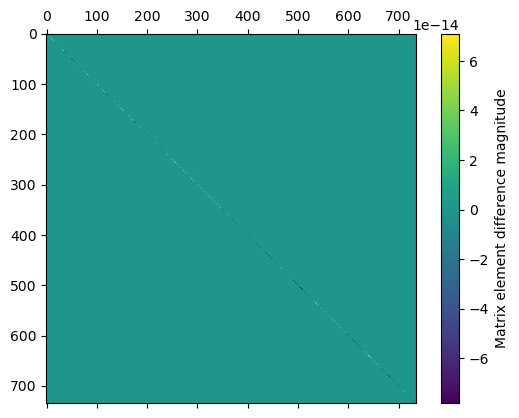

In [48]:
fig, ax = plt.subplots()
im = ax.matshow(full_hamiltonian-check_hamiltonian)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Matrix element difference magnitude')
plt.show()

In [50]:
max_diff = np.max(full_hamiltonian-check_hamiltonian)
print(max_diff)
print(np.argwhere((full_hamiltonian-check_hamiltonian-max_diff)==0))

7.105427357601002e-14
[[642 642]]


In [51]:
np.diag(check_hamiltonian)-np.diag(full_hamiltonian)

array([ 2.84217094e-14,  0.00000000e+00, -1.42108547e-14,  1.42108547e-14,
        1.42108547e-14, -1.42108547e-14, -2.84217094e-14, -1.42108547e-14,
       -2.13162821e-14, -4.26325641e-14, -4.26325641e-14, -3.55271368e-14,
       -2.84217094e-14, -4.26325641e-14, -3.55271368e-14,  2.84217094e-14,
        0.00000000e+00,  2.84217094e-14,  7.10542736e-15, -1.42108547e-14,
        0.00000000e+00,  0.00000000e+00, -1.42108547e-14, -2.13162821e-14,
        0.00000000e+00, -1.42108547e-14,  0.00000000e+00, -7.10542736e-15,
       -1.42108547e-14, -3.55271368e-14, -1.42108547e-14, -4.26325641e-14,
       -2.84217094e-14, -2.13162821e-14, -4.97379915e-14,  5.68434189e-14,
        2.84217094e-14,  2.84217094e-14,  2.84217094e-14,  2.84217094e-14,
        1.42108547e-14,  1.42108547e-14,  1.42108547e-14,  1.42108547e-14,
       -1.42108547e-14, -1.42108547e-14,  0.00000000e+00, -1.42108547e-14,
       -2.13162821e-14, -7.10542736e-15,  5.68434189e-14,  4.26325641e-14,
        5.68434189e-14,  